<h1> Gastric Cancer Proof of Concept </h1>
This notebook contains all the codes which were used in building the deep learning model for gastric cancer.
<br>

<h2> About the dataset </h2>
This dataset, the <b>Gastric Cancer Histopathology Tissue Image Dataset (GCHTID)</b>, is a valuable resource for researchers working on artificial intelligence in medical imaging, specifically for gastric cancer. It contains a large collection of expertly curated histopathology images.
<br>
The dataset focuses on the <b>tumor microenvironment (TME)</b> and includes images categorized into eight distinct tissue types:
<ul>
<li>ADI: Adipose (fat tissue)</li>
<li>BACK: Background (non-tissue areas)</li>
<li>DEB: Debris (cellular waste) </li>
<li>LYM: Lymphocytes (immune cells) </li>
<li>MUC: Mucus (protective secretion) </li>
<li>MUS: Smooth Muscle (muscle tissue) </li>
<li>NORM: Normal Colon Mucosa (healthy tissue for reference)</li>
<li>STR: Cancer-associated Stroma (connective tissue around the tumor)</li>
<li>TUM: Tumor (cancerous tissue) </li>
</ul>
<br>
The tissue categories were initially predicted using annotations from a publicly available colorectal cancer dataset to create tissue heatmaps. Subsequently, experienced pathologists selected 300 whole slide images with high prediction accuracy. Finally, the individual images belonging to the eight categories were extracted from these slides.
<br>


In [ ]:
# Load the libraries
import pathlib
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.layers import Rescaling
import math
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
image_height = 224
image_width = 224
batch_size = 32
seed = 1
dataset_url = "/content/drive/MyDrive/Gastric Cancer"

In [ ]:
train_ds = image_dataset_from_directory(
    dataset_url,
    validation_split=0.2,
    subset="training",
    seed = seed,
    image_size=(image_height, image_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)


Found 31118 files belonging to 8 classes.
Using 24895 files for training.


In [ ]:
test_ds = image_dataset_from_directory(
    dataset_url,
    validation_split=0.2,
    subset="validation",
    seed = seed,
    image_size=(image_height, image_width),
    batch_size=batch_size
)

Found 31118 files belonging to 8 classes.
Using 6223 files for validation.


In [ ]:
print(train_ds.class_names)
print(test_ds.class_names)


['ADI', 'DEB', 'LYM', 'MUC', 'MUS', 'NOR', 'STR', 'TUM']
['ADI', 'DEB', 'LYM', 'MUC', 'MUS', 'NOR', 'STR', 'TUM']


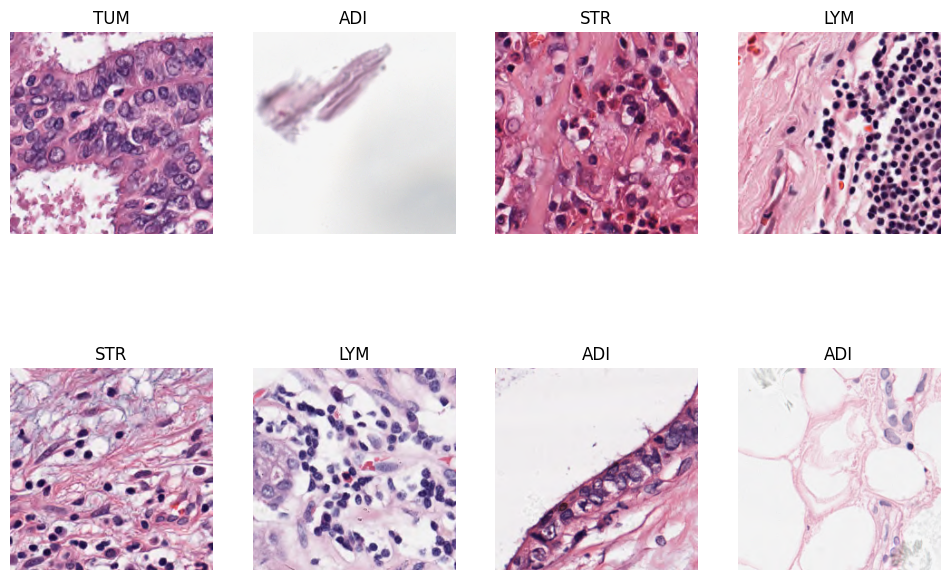

In [ ]:
class_names = train_ds.class_names
plt.figure(figsize=(12,8))

for images,labels in train_ds.take(1):
  for i in range(8):
    ax = plt.subplot(2,4, i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

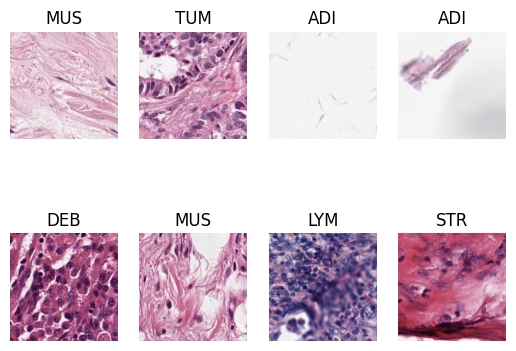

In [ ]:
for images,labels in train_ds.take(1):
  for i in range(8):
    ax = plt.subplot(2,4, i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [ ]:
def background_filter(
    image,
    label,
    sat_thresh = 0.15,
    min_tissue_ratio = 0.40
):

  # Removes tiles with large background
  image = tf.cast(image, tf.float32)/ 255.0
  hsv = tf.image.rgb_to_hsv(image)
  saturation = hsv[..., 1]

  tissue_mask = saturation > sat_thresh
  tissue_ratio = tf.reduce_mean(tf.cast(tissue_mask, tf.float32))

  return tissue_ratio >= min_tissue_ratio

In [ ]:
# Applying the filter
train_ds = train_ds.filter(
    lambda img, lbl: background_filter(img, lbl)
)

test_ds = test_ds.filter(
    lambda img, lbl: background_filter(img, lbl)
)

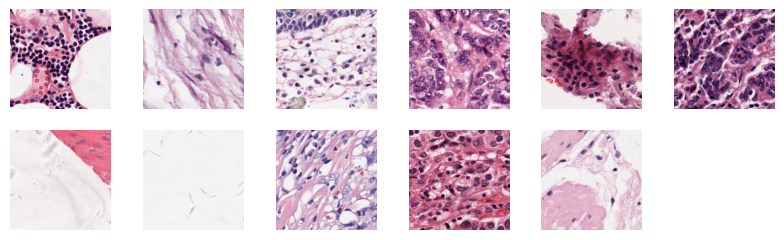

In [ ]:
plt.figure(figsize=(10, 6))

for images, labels in train_ds.take(1):
    for i in range(11):
        ax = plt.subplot(4, 6, i + 1)
        plt.imshow(tf.cast(images[i], tf.uint8))
        plt.axis("off")

plt.show()


In [ ]:
# check for the shape of train and test dataset
from collections import Counter


counter = Counter()

for _, labels in train_ds.unbatch():
    class_id = tf.argmax(labels).numpy()
    counter[class_id] += 1

print("Class distribution (after filtering):")
for i in range(num_classes):
    print(f"{class_names[i]}: {counter[i]}")


InvalidArgumentError: {{function_node __wrapped__ArgMax_device_/job:localhost/replica:0/task:0/device:CPU:0}} Expected dimension in the range [0, 0), but got 0 [Op:ArgMax] name: 